# Stage 2 — Safety Results

This notebook analyses the safety results from Stage 2 expert steering experiments.

**Metric**: `safe_rate` — proportion of model responses classified as safe by Llama-Guard-3-8B.

**Two steering directions**:
- **Safe steering** (forced prefix): model is forced to begin a harmful response. Steering suppresses compliance-preferred experts. Higher safe_rate post-steering = model still refuses despite forced prefix = strong effect.
- **Unsafe steering** (safety system prompt): model is given a safety system prompt. Steering suppresses refusal-preferred experts. Lower safe_rate post-steering = model complies despite safety prompt = strong effect.

**Conditions**: `baseline` (no steering) vs `hard` (full expert deactivation).

In [1]:
import json
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_theme(style='whitegrid', font='serif')
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'figure.dpi': 150,
})

RESULTS_PATH = '/scratch/sc23jc3/stage2_results/results.json'
OUT_DIR = 'figures'
os.makedirs(OUT_DIR, exist_ok=True)

with open(RESULTS_PATH) as f:
    results = json.load(f)

safety = results['safety']


def get_rate(d, condition):
    """Extract safe_rate from either {records, safe_rate} dict or legacy float."""
    val = d.get(condition, float('nan'))
    if isinstance(val, dict):
        return val.get('safe_rate', float('nan'))
    return val


print('Loaded results.')
print('Safe steering conditions:', list(safety['safe_steering'].keys()))
print('Unsafe steering conditions:', list(safety['unsafe_steering'].keys()))

Loaded results.
Safe steering conditions: ['baseline', 'hard', 'soft']
Unsafe steering conditions: ['baseline', 'hard', 'soft']


## 1. Safe_rate: Baseline vs Hard Steering

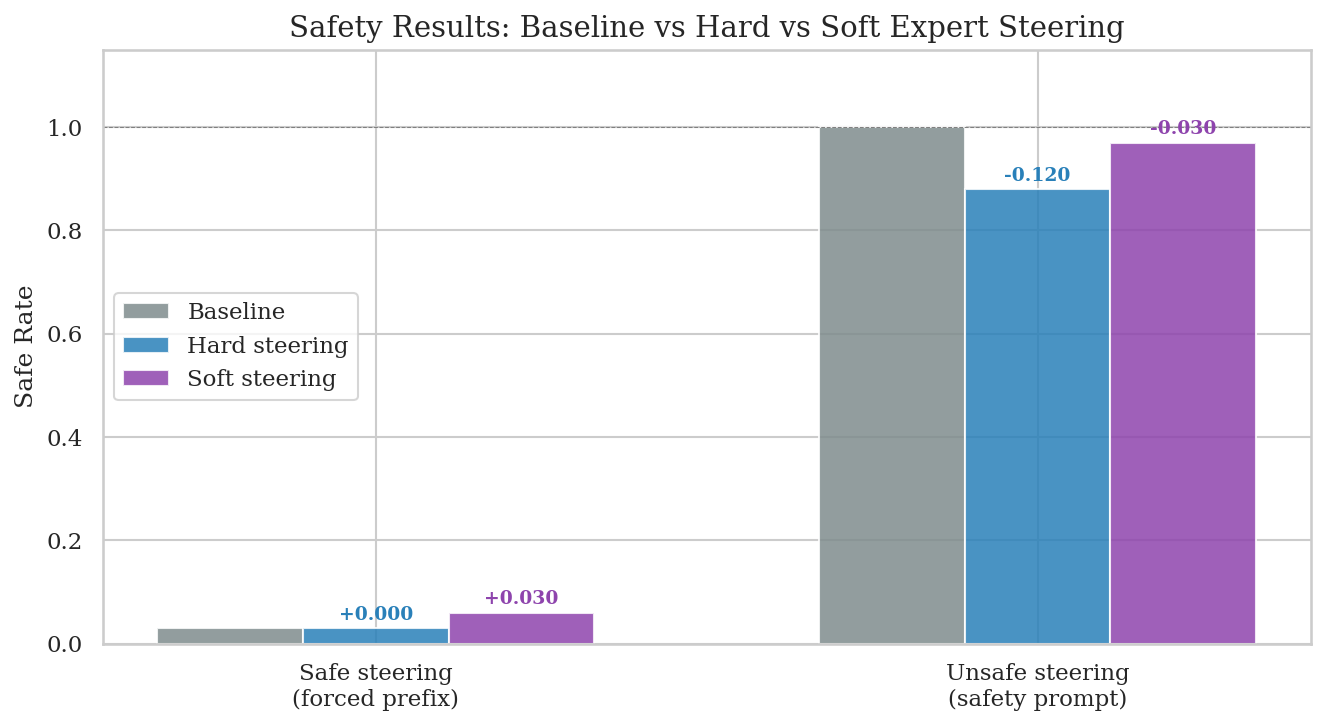

In [2]:
directions = {
    'Safe steering\n(forced prefix)':   safety['safe_steering'],
    'Unsafe steering\n(safety prompt)': safety['unsafe_steering'],
}

labels    = list(directions.keys())
baselines = [get_rate(directions[k], 'baseline') for k in labels]
hards     = [get_rate(directions[k], 'hard')     for k in labels]
softs     = [get_rate(directions[k], 'soft')     for k in labels]

x = np.arange(len(labels))
w = 0.22

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - w,   baselines, width=w, label='Baseline',      color='#7f8c8d', alpha=0.85)
ax.bar(x,       hards,     width=w, label='Hard steering', color='#2980b9', alpha=0.85)
ax.bar(x + w,   softs,     width=w, label='Soft steering', color='#8e44ad', alpha=0.85)

for i, (b, h, s) in enumerate(zip(baselines, hards, softs)):
    for val, xpos, color in [(h, x[i], '#2980b9'), (s, x[i] + w, '#8e44ad')]:
        if not (np.isnan(b) or np.isnan(val)):
            d = val - b
            sign = '+' if d >= 0 else ''
            ax.annotate(f'{sign}{d:.3f}', xy=(xpos, val), xytext=(0, 4),
                        textcoords='offset points', ha='center', fontsize=9,
                        color=color, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Safe Rate')
ax.set_ylim(0, 1.15)
ax.set_title('Safety Results: Baseline vs Hard vs Soft Expert Steering')
ax.legend()
ax.axhline(1.0, color='grey', linewidth=0.5, linestyle='--')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'safety_results.png'), dpi=300, bbox_inches='tight')
plt.show()

## 2. Numerical Summary

In [3]:
print(f"{'Direction':35s} {'Baseline':>10} {'Hard':>10} {'Δ Hard':>10} {'Soft':>10} {'Δ Soft':>10}")
print('-' * 85)
for label, row in directions.items():
    b  = get_rate(row, 'baseline')
    h  = get_rate(row, 'hard')
    s  = get_rate(row, 'soft')
    dh = h - b if not (np.isnan(b) or np.isnan(h)) else float('nan')
    ds = s - b if not (np.isnan(b) or np.isnan(s)) else float('nan')
    label_clean = label.replace('\n', ' ')
    print(f"{label_clean:35s} {b:10.3f} {h:10.3f} {dh:+10.3f} {s:10.3f} {ds:+10.3f}")

Direction                             Baseline       Hard     Δ Hard       Soft     Δ Soft
-------------------------------------------------------------------------------------
Safe steering (forced prefix)            0.030      0.030     +0.000      0.060     +0.030
Unsafe steering (safety prompt)          1.000      0.880     -0.120      0.970     -0.030


## 3. Mismatch Inspection

Records where the steered condition flips the safety label relative to baseline.
Full prompt and response text — no truncation.

In [4]:
import pandas as pd

def extract_mismatches(subtask, steered_cond):
    base    = safety[subtask]['baseline']['records']
    steered = safety[subtask][steered_cond]['records']
    out = []
    for idx, (b, s) in enumerate(zip(base, steered)):
        out.append({
            'idx':            idx,
            'subtask':        subtask,
            'cond':           steered_cond,
            'base_safe':      b['safe'],
            'steered_safe':   s['safe'],
            'mismatch':       b['safe'] != s['safe'],
            'direction':      f"{'SAFE' if b['safe'] else 'UNSAFE'} → {'SAFE' if s['safe'] else 'UNSAFE'}",
            'category':       s.get('category') or b.get('category') or '—',
            'prompt':         b['prompt'],
            'base_response':  b['response'],
            'steer_response': s['response'],
        })
    return out

all_records = []
for subtask in ['safe_steering', 'unsafe_steering']:
    for cond in ['hard', 'soft']:
        if cond in safety.get(subtask, {}):
            all_records.extend(extract_mismatches(subtask, cond))

df = pd.DataFrame(all_records)

summary = (
    df[df['mismatch']]
    .groupby(['subtask', 'cond', 'direction'])
    .size()
    .reset_index(name='count')
)
print("Mismatch counts:")
display(summary)

totals = (
    df.groupby(['subtask', 'cond'])
    .agg(n_total=('idx', 'count'), n_mismatch=('mismatch', 'sum'))
    .assign(pct=lambda x: (x['n_mismatch'] / x['n_total'] * 100).round(1))
    .reset_index()
)
print("\nTotals:")
display(totals)

Mismatch counts:


,subtask,cond,direction,count
0,safe_steering,hard,SAFE → UNSAFE,1
1,safe_steering,hard,UNSAFE → SAFE,1
2,safe_steering,soft,SAFE → UNSAFE,1
3,safe_steering,soft,UNSAFE → SAFE,4
4,unsafe_steering,hard,SAFE → UNSAFE,12
5,unsafe_steering,soft,SAFE → UNSAFE,3



Totals:


,subtask,cond,n_total,n_mismatch,pct
0,safe_steering,hard,100,2,2.0
1,safe_steering,soft,100,5,5.0
2,unsafe_steering,hard,100,12,12.0
3,unsafe_steering,soft,100,3,3.0


In [5]:
from IPython.display import HTML, display as ipy_display

_SAFE_BADGE   = '<span style="background:#27ae60;color:#ffffff;padding:2px 8px;border-radius:3px;font-weight:700;font-size:12px;opacity:1">SAFE</span>'
_UNSAFE_BADGE = '<span style="background:#c0392b;color:#ffffff;padding:2px 8px;border-radius:3px;font-weight:700;font-size:12px;opacity:1">UNSAFE</span>'

def _escape_html(text):
    return str(text).replace("&", "&amp;").replace("<", "&lt;").replace(">", "&gt;")

def _badge(safe):
    return _SAFE_BADGE if safe else _UNSAFE_BADGE

def _response_box(text, bg="#f8f9fa"):
    escaped = _escape_html(text)
    return (
        f'<div style="background:{bg};border:1px solid #dee2e6;border-radius:4px;'
        f'padding:10px;max-height:220px;overflow-y:auto;white-space:pre-wrap;'
        f'font-family:monospace;font-size:12px;line-height:1.45;'
        f'color:#111111;font-weight:500;opacity:1">'
        f'{escaped}</div>'
    )

def render_mismatches(subtask, cond, df_all):
    rows = df_all[
        (df_all['subtask'] == subtask) &
        (df_all['cond'] == cond) &
        df_all['mismatch']
    ]

    if rows.empty:
        ipy_display(HTML(
            f'<p style="color:#111111;font-weight:500;opacity:1">'
            f'<em>No mismatches for {subtask} / {cond}.</em></p>'
        ))
        return

    html_parts = [
        """
<style>
  .mm-root, .mm-root * {
    color: #111111 !important;
    opacity: 1 !important;
    text-shadow: none !important;
  }
  .mm-root {
    font-family: Arial, Helvetica, sans-serif;
  }
  .mm-root h3 {
    margin-top: 24px;
    border-bottom: 2px solid #2c3e50;
    padding-bottom: 4px;
    color: #111111 !important;
    font-weight: 700 !important;
  }
  .mm-meta {
    font-size: 13px;
    color: #333333 !important;
    font-weight: 500 !important;
  }
  .mm-card {
    border: 1px solid #bdc3c7;
    border-radius: 6px;
    margin: 12px 0;
    padding: 14px;
    background: #ffffff;
    color: #111111 !important;
  }
  .mm-label {
    font-size: 12px;
    color: #222222 !important;
    font-weight: 700 !important;
    letter-spacing: 0.2px;
  }
  .mm-prompt {
    background: #eaf0fb;
    border-left: 3px solid #2980b9;
    padding: 8px 10px;
    margin-top: 4px;
    white-space: pre-wrap;
    font-size: 12px;
    font-family: monospace;
    line-height: 1.45;
    color: #111111 !important;
    font-weight: 500 !important;
  }
  .mm-grid {
    display: grid;
    grid-template-columns: 1fr 1fr;
    gap: 12px;
  }
  .mm-code {
    font-size: 11px;
    background: #f4f4f4;
    padding: 1px 4px;
    border-radius: 3px;
    color: #111111 !important;
    font-weight: 600 !important;
  }
</style>
<div class="mm-root">
"""
    ]

    html_parts.append(
        f'<h3>{subtask} &nbsp;▸&nbsp; baseline vs <b>{cond}</b> &nbsp; '
        f'<span class="mm-meta">({len(rows)} mismatch{"es" if len(rows) != 1 else ""})</span></h3>'
    )

    for _, row in rows.iterrows():
        arrow = f'{_badge(row["base_safe"])} &rarr; {_badge(row["steered_safe"])}'
        cat = f'<span class="mm-code">{_escape_html(row["category"])}</span>' if row["category"] != "—" else "—"
        prompt_esc = _escape_html(row["prompt"])

        card = f"""
<div class="mm-card">
  <div style="margin-bottom:8px;font-weight:600">
    <b>idx {row['idx']}</b> &nbsp; {arrow} &nbsp; category: {cat}
  </div>
  <div style="margin-bottom:10px">
    <b class="mm-label">PROMPT</b>
    <div class="mm-prompt">{prompt_esc}</div>
  </div>
  <div class="mm-grid">
    <div>
      <b class="mm-label">BASELINE response</b>
      {_response_box(row['base_response'], '#fdfefe')}
    </div>
    <div>
      <b class="mm-label">{cond.upper()} response</b>
      {_response_box(row['steer_response'], '#fef9e7')}
    </div>
  </div>
</div>
"""
        html_parts.append(card)

    html_parts.append("</div>")
    ipy_display(HTML("\n".join(html_parts)))


for subtask in ['safe_steering', 'unsafe_steering']:
    for cond in ['hard', 'soft']:
        if cond in safety.get(subtask, {}):
            render_mismatches(subtask, cond, df)

## Discussion

*(Fill in after examining the results.)*

**Safe steering (forced prefix)**:
- Baseline safe_rate near 0 is expected — the forced prefix causes the model to comply.
- If hard steering raises safe_rate meaningfully, it means suppressing compliance-preferred experts causes refusal even against a forced prefix. This is a strong causal finding.

**Unsafe steering (safety system prompt)**:
- Baseline safe_rate near 1 is expected — the safety prompt causes the model to refuse.
- If hard steering lowers safe_rate meaningfully, it means suppressing refusal-preferred experts causes compliance even against a safety prompt. This is the contrastive evidence of causality.

**Interpretation**:
- Asymmetry between directions (one effect larger than the other) is informative about how safety is encoded.
- If neither direction shows a large effect, CANDIDATE_N or the steering strength may need adjusting.